<a href="https://colab.research.google.com/github/Tirthalg/DNA-Sequencing/blob/main/Fake%20audio%20detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

fake_audio_dir = '/content/drive/MyDrive/data/real'
original_audio_dir = '/content/drive/MyDrive/data/fake'

In [ ]:
import pandas as pd

file_paths = []
labels = []

for filename in os.listdir(fake_audio_dir):
    if filename.endswith('.wav') or filename.endswith('.mp3'):
        file_paths.append(os.path.join(fake_audio_dir, filename))
        labels.append('fake')

for filename in os.listdir(original_audio_dir):
    if filename.endswith('.wav') or filename.endswith('.mp3'):
        file_paths.append(os.path.join(original_audio_dir, filename))
        labels.append('original')

data = {'file_path': file_paths, 'label': labels}
df = pd.DataFrame(data)

In [ ]:
csv_file_path = '/content/drive/MyDrive/audio_labels.csv'

df.to_csv(csv_file_path, index=False)

print(f"CSV file created at: {csv_file_path}")

CSV file created at: /content/drive/MyDrive/audio_labels.csv


In [ ]:
df = pd.read_csv(csv_file_path)

print(df.head())


                                         file_path label
0  /content/drive/MyDrive/data/real/LJ034-0110.wav  fake
1  /content/drive/MyDrive/data/real/LJ034-0128.wav  fake
2  /content/drive/MyDrive/data/real/LJ034-0133.wav  fake
3  /content/drive/MyDrive/data/real/LJ034-0180.wav  fake
4  /content/drive/MyDrive/data/real/LJ034-0102.wav  fake


In [ ]:
df_shuffled = df.sample(frac=1, random_state=511).reset_index(drop=True)
print(df_shuffled['file_path'][0])
print(df_shuffled.head())


/content/drive/MyDrive/data/real/LJ025-0113.wav
                                           file_path     label
0    /content/drive/MyDrive/data/real/LJ025-0113.wav      fake
1    /content/drive/MyDrive/data/real/LJ016-0172.wav      fake
2  /content/drive/MyDrive/data/fake/LJ008-0196_ge...  original
3  /content/drive/MyDrive/data/fake/LJ011-0235_ge...  original
4    /content/drive/MyDrive/data/real/LJ036-0149.wav      fake


In [ ]:

# X = df_shuffled['file_path']
# y = df_shuffled['label']

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# print(f"Training set size: {len(X_train)}")
# print(f"Testing set size: {len(X_test)}")

In [ ]:
!pip install librosa matplotlib --quiet

import librosa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, sr=None)
        # if len(y) < 1024:
        #     y = np.pad(y, (0, 1024 - len(y)), mode='constant')
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma.T, axis=0)

        mfccs = librosa.feature.mfcc(y=y, sr=sr)
        mfccs_mean = np.mean(mfccs.T, axis=0)

        spect_band = librosa.feature.spectral_bandwidth(y=y,sr=sr)
        specb_mean = np.mean(spect_band.T, axis=0)

        spect_cen = librosa.feature.spectral_centroid(y=y,sr=sr)
        specc_mean = np.mean(spect_cen.T,axis=0)

        spect_flat = librosa.feature.spectral_flatness(y=y)
        specf_mean = np.mean(spect_flat.T , axis=0)

        spect_con = librosa.feature.spectral_contrast(y=y,sr=sr)
        specco_mean = np.mean(spect_con.T, axis=0)

        tonz = librosa.feature.tonnetz(y=y,sr=sr)
        ton_mean = np.mean(tonz.T, axis = 0)

        # return (chroma,chroma_mean, mfccs,mfccs_mean, spect_band,specb_mean,spect_cen,specc_mean,spect_flat,specf_mean,spect_con,specco_mean,tonz,ton_mean)
        return np.hstack([chroma_mean, mfccs_mean, specb_mean,specc_mean,specf_mean,specco_mean,ton_mean])

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

In [ ]:
print(extract_features(df_shuffled['file_path'][0]),df_shuffled['label'][0])
print(extract_features(df_shuffled['file_path'][1]),df_shuffled['label'][1])
df_shuffled.shape

[ 3.29981297e-01  3.25084537e-01  2.82794803e-01  2.94200093e-01
  2.58675963e-01  3.18092257e-01  3.79862994e-01  3.70821625e-01
  3.86316538e-01  3.79601389e-01  3.93723756e-01  3.58203113e-01
 -3.02898163e+02  7.55509415e+01  6.71221316e-01  2.06331329e+01
 -1.65604897e+01 -2.07420101e+01 -2.05652580e+01 -1.98697567e+01
 -1.92419968e+01  4.03640366e+00 -1.93508453e+01 -6.31689882e+00
 -8.24147224e+00  6.23842478e+00 -9.86787415e+00 -9.10722542e+00
 -5.52040911e+00 -2.54396844e+00 -4.47771358e+00 -1.04873934e+01
  2.01929757e+03  2.72930662e+03  3.16139087e-02  2.40704443e+01
  1.66683202e+01  1.86877523e+01  1.73490604e+01  1.99302573e+01
  2.21564080e+01  2.81287410e+01 -6.13875997e-03 -1.30235638e-02
  1.56147554e-03 -1.15904368e-02 -8.02397523e-03  4.18682711e-03] fake
[ 3.31877828e-01  2.74236083e-01  3.37691545e-01  4.03851897e-01
  3.25619578e-01  2.85145015e-01  3.09189051e-01  3.51588190e-01
  3.91387969e-01  4.62419122e-01  4.20366287e-01  3.77837449e-01
 -3.07957733e+02  5

(20000, 2)

In [ ]:
features_list = []
for i in range(0, 1500):
    features_list.append(extract_features(df_shuffled['file_path'][i]))
features_matrix = np.array(features_list)

df = pd.DataFrame(features_list)
df = pd.concat([df, df_shuffled['label'][:1500]], axis=1)

df.shape

/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=788
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=640
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=951
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=952
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=796
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=695
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: 

(1500, 49)

In [ ]:
# df = pd.read_csv('/content/drive/MyDrive/final.csv')

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and labels
X = df.drop('label', axis=1)
y = df['label']

# Encode labels (if necessary, depending on your ML model)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
print(df.head)
df.shape

csv_file_path = '/content/drive/MyDrive/final.csv'

df.to_csv(csv_file_path, index=False)

print(f"CSV file created at: {csv_file_path}")

<bound method NDFrame.head of              0         1         2         3         4         5         6  \
0     0.329981  0.325085  0.282795  0.294200  0.258676  0.318092  0.379863   
1     0.331878  0.274236  0.337692  0.403852  0.325620  0.285145  0.309189   
2     0.338642  0.312113  0.295567  0.326091  0.282451  0.259013  0.296901   
3     0.458745  0.375715  0.293125  0.333649  0.362399  0.395691  0.338318   
4     0.309693  0.284060  0.282980  0.256350  0.256327  0.284144  0.348495   
...        ...       ...       ...       ...       ...       ...       ...   
1495  0.378619  0.359684  0.284123  0.269588  0.296962  0.285080  0.335949   
1496  0.370473  0.296774  0.255596  0.277551  0.298889  0.308635  0.311159   
1497  0.344077  0.269404  0.245105  0.272219  0.280739  0.366743  0.327089   
1498  0.263211  0.266070  0.246225  0.274489  0.273055  0.287017  0.313189   
1499  0.319732  0.283296  0.340504  0.400635  0.377424  0.346874  0.296075   

             7         8         

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

Model: GradientBoostingClassifier
Accuracy: 0.87
Precision: 0.89
Recall: 0.85
F1 Score: 0.87

Confusion Matrix:
[[137  16]
 [ 22 125]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       153
           1       0.89      0.85      0.87       147

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300



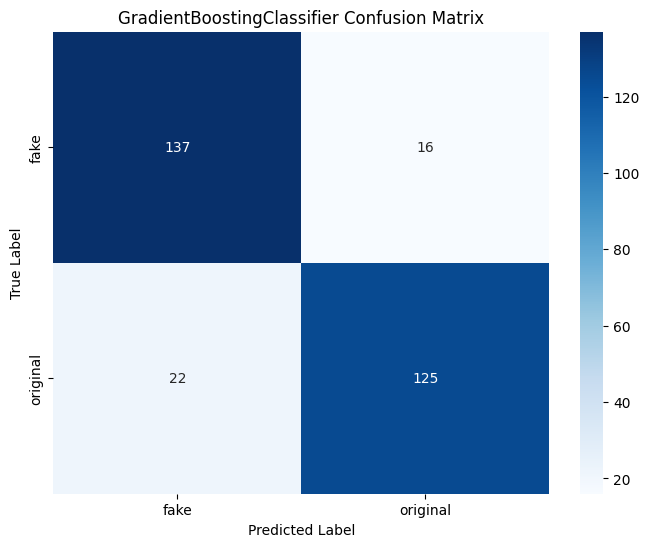

Confusion matrix saved as GradientBoostingClassifier_confusion_matrix.png
Model: RandomForestClassifier
Accuracy: 0.84
Precision: 0.85
Recall: 0.83
F1 Score: 0.84

Confusion Matrix:
[[131  22]
 [ 25 122]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       153
           1       0.85      0.83      0.84       147

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300



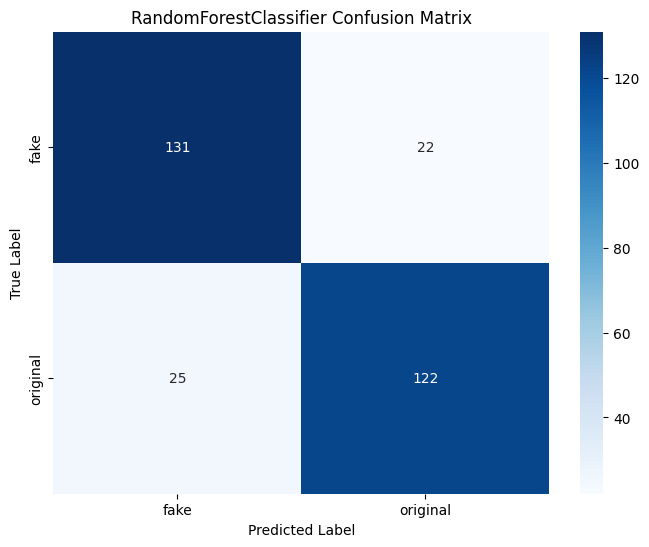

Confusion matrix saved as RandomForestClassifier_confusion_matrix.png
Model: GaussianNB
Accuracy: 0.80
Precision: 0.80
Recall: 0.80
F1 Score: 0.80

Confusion Matrix:
[[123  30]
 [ 30 117]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       153
           1       0.80      0.80      0.80       147

    accuracy                           0.80       300
   macro avg       0.80      0.80      0.80       300
weighted avg       0.80      0.80      0.80       300



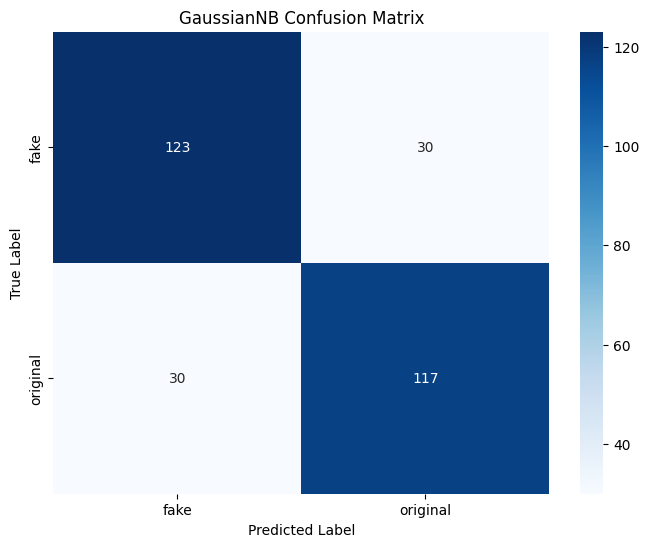

Confusion matrix saved as GaussianNB_confusion_matrix.png
Model: LogisticRegression
Accuracy: 0.66
Precision: 0.66
Recall: 0.64
F1 Score: 0.65

Confusion Matrix:
[[104  49]
 [ 53  94]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.68      0.67       153
           1       0.66      0.64      0.65       147

    accuracy                           0.66       300
   macro avg       0.66      0.66      0.66       300
weighted avg       0.66      0.66      0.66       300



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


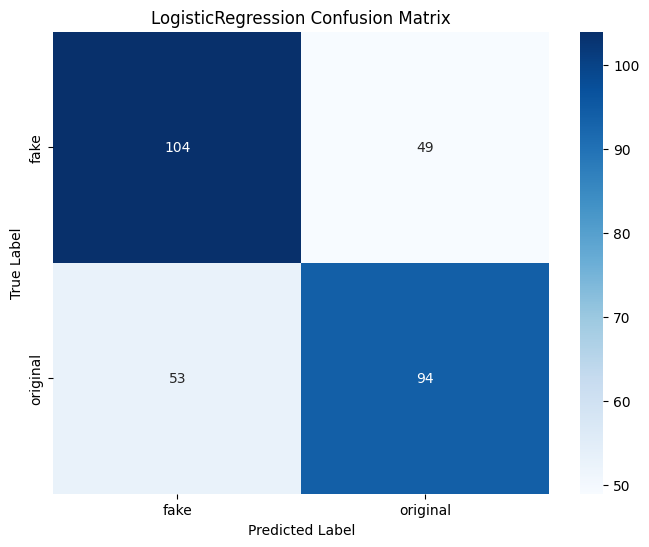

Confusion matrix saved as LogisticRegression_confusion_matrix.png
Model: SVC
Accuracy: 0.54
Precision: 0.69
Recall: 0.12
F1 Score: 0.21

Confusion Matrix:
[[145   8]
 [129  18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.95      0.68       153
           1       0.69      0.12      0.21       147

    accuracy                           0.54       300
   macro avg       0.61      0.54      0.44       300
weighted avg       0.61      0.54      0.45       300



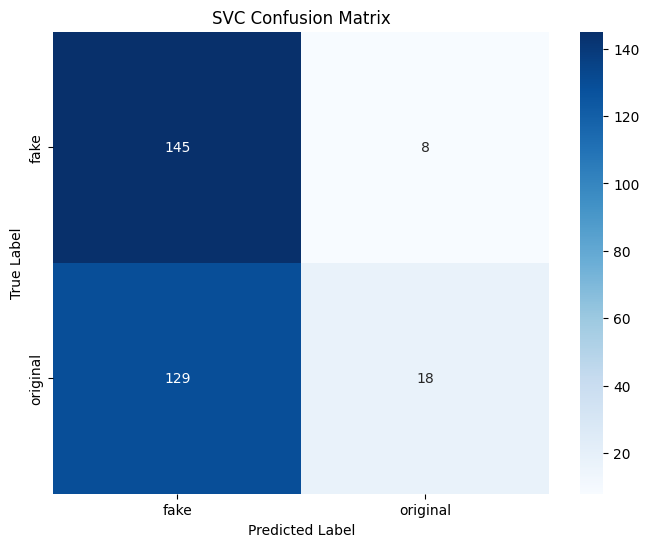

Confusion matrix saved as SVC_confusion_matrix.png
Model: KNeighborsClassifier
Accuracy: 0.54
Precision: 0.53
Recall: 0.54
F1 Score: 0.54

Confusion Matrix:
[[82 71]
 [67 80]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.54      0.54       153
           1       0.53      0.54      0.54       147

    accuracy                           0.54       300
   macro avg       0.54      0.54      0.54       300
weighted avg       0.54      0.54      0.54       300



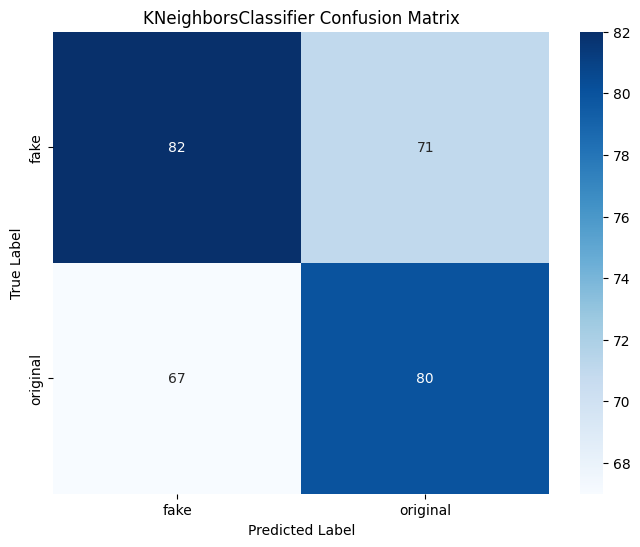

Confusion matrix saved as KNeighborsClassifier_confusion_matrix.png
Model: MLPClassifier
Accuracy: 0.54
Precision: 0.57
Recall: 0.28
F1 Score: 0.37

Confusion Matrix:
[[122  31]
 [106  41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.80      0.64       153
           1       0.57      0.28      0.37       147

    accuracy                           0.54       300
   macro avg       0.55      0.54      0.51       300
weighted avg       0.55      0.54      0.51       300



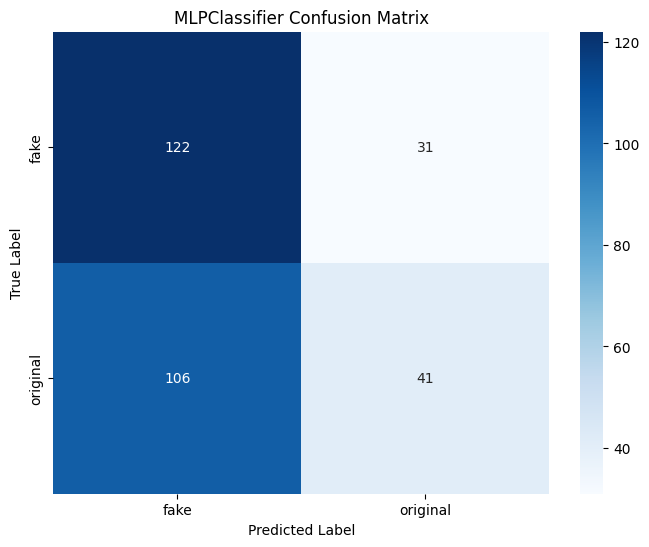

Confusion matrix saved as MLPClassifier_confusion_matrix.png


In [ ]:

classifiers = {
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(random_state=42),
    "Support Vector Machine": SVC(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Neural Network (MLP)": MLPClassifier(random_state=42),
}
def save_confusion_matrix_heatmap(conf_matrix, model_name, label_encoder):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{model_name} Confusion Matrix')

    file_path = f"{model_name}_confusion_matrix.png"
    plt.show()
    # plt.savefig(file_path, format='png', dpi=300)
    # plt.close()

    print(f"Confusion matrix saved as {file_path}")

def evaluate_model(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    print(f"Model: {model.__class__.__name__}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")
    print("\nConfusion Matrix:")
    print(conf_matrix)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    save_confusion_matrix_heatmap(conf_matrix,model.__class__.__name__,label_encoder)


# Loop through classifiers and evaluate each
for name, model in classifiers.items():
    evaluate_model(model)